Loading data...
Train: 2014-01-01 to 2021-05-31 (obs: 0)
Test:  2021-10-01 to 2023-12-30 (obs: 37)
Training...
  Epoch 25: Loss=0.305
  Epoch 50: Loss=0.255
  Epoch 75: Loss=0.223
  Epoch 100: Loss=0.197

ERA5 MAE=19.84, PINN MAE=19.60
ERA5 RMSE=25.96, PINN RMSE=25.71
ERA5 NSE=0.746, PINN NSE=0.751
Wilcoxon p-value: 0.1406


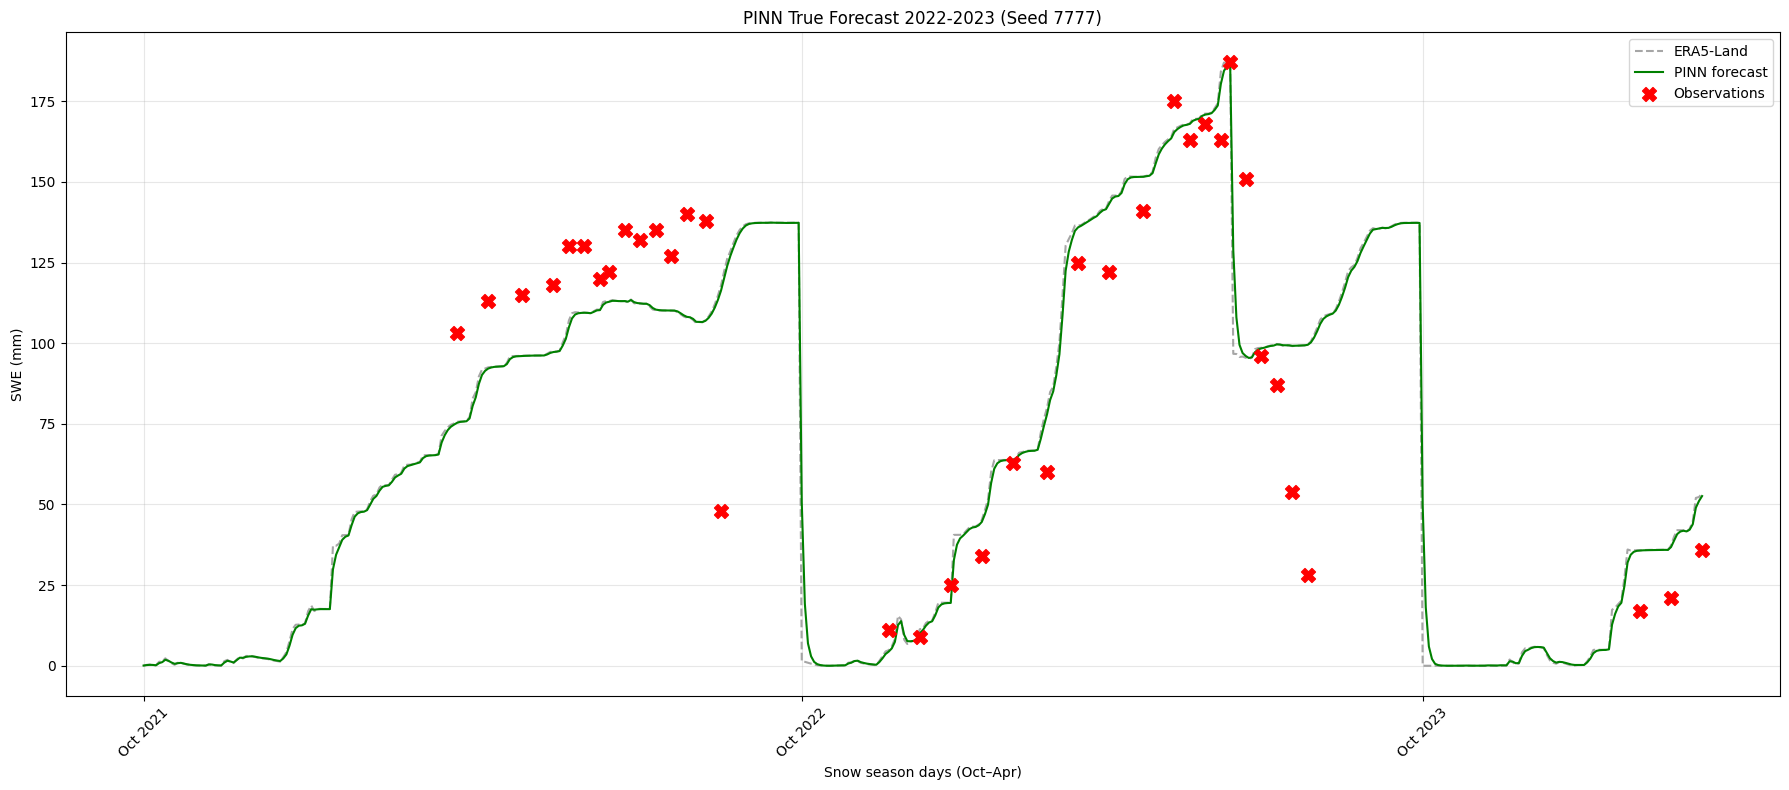


✅ Forecast experiment completed.


In [2]:
# ============================================================
# Supplementary: PINN True Forecast 2022-2023
# ============================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# Configuration
# ============================================================
SEED = 7777
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
FIG_DIR = 'figures'
TABLE_DIR = 'tables'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

DATA_PATH = '../../data_preprocessing/processed/shemonaikha_snow_dataset_2014_2023.csv'
OBS_PATH = '../../data_preprocessing/data/shemonaikha.csv'

# ============================================================
# Load data
# ============================================================
print("Loading data...")
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['era5_swe'] = df['swe_final']

obs = pd.read_csv(OBS_PATH)
obs['Date'] = obs['Date'].astype(str).str.replace('"', '').str.strip()
obs['Date'] = obs['Date'].str.replace(',$', '', regex=True)
obs['Date'] = pd.to_datetime(obs['Date'], format='%d.%m.%Y %H:%M')
obs['SWE'] = pd.to_numeric(obs['SWE'].astype(str).str.replace('"', '').str.replace(',', ''), errors='coerce')
obs['date'] = obs['Date'].dt.date
obs = obs.drop_duplicates(subset=['date']).copy()
obs['date'] = pd.to_datetime(obs['date'])
station_dict = dict(zip(obs['date'], obs['SWE']))
df['observed_swe'] = df['date'].map(station_dict)

df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['water_year'] = df['year'] + (df['month'] >= 10).astype(int)
df_snow = df[(df['month'] >= 10) | (df['month'] <= 5)].copy().reset_index(drop=True)

# ============================================================
# Feature engineering
# ============================================================
def create_features(df_subset):
    n = len(df_subset)
    def get_vals(col):
        vals = df_subset[col]
        return vals.iloc[:, 0].values if isinstance(vals, pd.DataFrame) else vals.values

    temp = get_vals('temperature_2m_C')
    precip = get_vals('precipitation_mm')
    snow_cover = get_vals('snow_cover_ERA5')
    albedo = get_vals('forecast_albedo')
    snowmelt = get_vals('snowmelt_sum')
    solar_down = get_vals('surface_solar_radiation_downwards_sum')
    thermal_down = get_vals('surface_thermal_radiation_downwards_sum')
    u_wind = get_vals('u_component_of_wind_10m')
    v_wind = get_vals('v_component_of_wind_10m')
    soil_water = get_vals('volumetric_soil_water_layer_1')
    water_year = get_vals('water_year')
    doy = get_vals('doy')

    features = {}
    features['temperature_2m_C'] = temp
    features['precipitation_mm'] = precip
    features['snow_cover_ERA5'] = snow_cover
    features['forecast_albedo'] = albedo
    features['snowmelt_sum'] = snowmelt
    features['surface_solar_radiation_downwards_sum'] = solar_down
    features['surface_thermal_radiation_downwards_sum'] = thermal_down
    features['u_component_of_wind_10m'] = u_wind
    features['v_component_of_wind_10m'] = v_wind
    features['volumetric_soil_water_layer_1'] = soil_water

    features['wind_speed'] = np.sqrt(u_wind**2 + v_wind**2)
    albedo_clipped = np.clip(albedo, 0.3, 0.95)
    features['solar_net'] = solar_down * (1 - albedo_clipped)
    features['thermal_net'] = (thermal_down - 5.67e-8 * 273.15**4) / 1e6
    features['temp_melt_potential'] = np.maximum(temp - 0.5, 0)
    features['soil_moisture_pct'] = soil_water * 100
    features['doy_sin'] = np.sin(2 * np.pi * doy / 365)
    features['doy_cos'] = np.cos(2 * np.pi * doy / 365)

    unique_wy = np.unique(water_year)
    for lag in [1, 2, 3]:
        temp_lag = np.full(n, np.nan)
        precip_lag = np.full(n, np.nan)
        for wy in unique_wy:
            mask = water_year == wy
            idx = np.where(mask)[0]
            if len(idx) > lag:
                temp_lag[idx[lag:]] = temp[idx[:-lag]]
                precip_lag[idx[lag:]] = precip[idx[:-lag]]
        features[f'temp_lag{lag}'] = temp_lag
        features[f'precip_lag{lag}'] = precip_lag

    cumul_precip = np.full(n, np.nan)
    cumul_snowmelt = np.full(n, np.nan)
    for wy in unique_wy:
        mask = water_year == wy
        cumul_precip[mask] = np.cumsum(precip[mask])
        cumul_snowmelt[mask] = np.cumsum(snowmelt[mask])
    features['cumul_precip'] = cumul_precip
    features['cumul_snowmelt'] = cumul_snowmelt

    df_feat = pd.DataFrame(features, index=df_subset.index)
    df_feat = df_feat.ffill().fillna(0)
    return df_feat

# ============================================================
# PINN model and loss
# ============================================================
class StablePINN(nn.Module):
    def __init__(self, feature_names):
        super().__init__()
        self.feature_names = feature_names
        self.raw_temp_melt = nn.Parameter(torch.tensor(0.5))
        self.raw_solar_melt = nn.Parameter(torch.tensor(-2.0))
        self.raw_thermal_melt = nn.Parameter(torch.tensor(-2.5))
        self.raw_wind_subl = nn.Parameter(torch.tensor(-3.0))
        self.raw_snow_threshold = nn.Parameter(torch.tensor(0.3))
        self.physics_weight = nn.Parameter(torch.tensor(0.5))
        self.era5_weight = nn.Parameter(torch.tensor(0.5))
        self.corrector = nn.Sequential(
            nn.Linear(12, 24), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(24, 12), nn.ReLU(), nn.Linear(12, 1), nn.Tanh()
        )
        self.correction_scale = nn.Parameter(torch.tensor(1.0))

    @property
    def temp_melt_factor(self):
        return torch.nn.functional.softplus(self.raw_temp_melt) * 2.0
    @property
    def solar_melt_factor(self):
        return torch.nn.functional.softplus(self.raw_solar_melt) * 0.05
    @property
    def thermal_melt_factor(self):
        return torch.nn.functional.softplus(self.raw_thermal_melt) * 0.01
    @property
    def wind_sublimation_factor(self):
        return torch.nn.functional.softplus(self.raw_wind_subl) * 0.01
    @property
    def snow_threshold(self):
        return torch.nn.functional.softplus(self.raw_snow_threshold) + 0.5

    def _get_idx(self, name):
        return self.feature_names.index(name)

    def physics_forward(self, x):
        t = x[:, self._get_idx('temperature_2m_C')]
        p = x[:, self._get_idx('precipitation_mm')]
        sc = x[:, self._get_idx('snow_cover_ERA5')] / 100.0
        sn = x[:, self._get_idx('solar_net')]
        tn = x[:, self._get_idx('thermal_net')]
        w = x[:, self._get_idx('wind_speed')]
        sm = x[:, self._get_idx('soil_moisture_pct')]
        tp = x[:, self._get_idx('temp_melt_potential')]

        snow_frac = torch.sigmoid(-3 * (t - self.snow_threshold))
        snowfall = p * snow_frac * torch.clamp(sc, min=0.05)
        temp_melt = self.temp_melt_factor * tp * sc
        solar_melt = self.solar_melt_factor * torch.clamp(sn, min=0) * sc
        thermal_melt = self.thermal_melt_factor * torch.clamp(tn, min=0) * sc
        soil_melt = 0.001 * sm * sc * tp
        sub_cond = torch.sigmoid(2 * (t + 5))
        sublimation = self.wind_sublimation_factor * w * sc * sub_cond
        total_melt = temp_melt + solar_melt + thermal_melt + soil_melt
        dswe_dt = snowfall - total_melt - sublimation
        return dswe_dt, snowfall, total_melt, sublimation

    def forward(self, x, swe_prev, era5_current, era5_prev):
        if x.dim() == 1:
            x = x.unsqueeze(0)
        dswe_dt, snowfall, total_melt, sublimation = self.physics_forward(x)
        swe_physics = swe_prev + dswe_dt.unsqueeze(1)
        swe_physics = torch.clamp(swe_physics, min=0)
        w_phys = torch.sigmoid(self.physics_weight)
        w_era5 = torch.sigmoid(self.era5_weight)
        swe_blend = (w_phys * swe_physics + w_era5 * era5_current) / (w_phys + w_era5 + 1e-8)
        corr_features = torch.cat([
            dswe_dt.unsqueeze(1), snowfall.unsqueeze(1),
            total_melt.unsqueeze(1), sublimation.unsqueeze(1),
            (swe_physics - era5_current), (swe_prev - era5_prev),
            x[:, self._get_idx('temperature_2m_C')].unsqueeze(1),
            x[:, self._get_idx('snow_cover_ERA5')].unsqueeze(1) / 100.0,
            x[:, self._get_idx('cumul_precip')].unsqueeze(1) / 200.0,
            x[:, self._get_idx('cumul_snowmelt')].unsqueeze(1) / 200.0,
            x[:, self._get_idx('doy_sin')].unsqueeze(1),
            x[:, self._get_idx('doy_cos')].unsqueeze(1)
        ], dim=1)
        scale = torch.nn.functional.softplus(self.correction_scale) * 10.0
        correction = self.corrector(corr_features) * scale
        swe_corrected = swe_blend + correction
        swe_corrected = torch.clamp(swe_corrected, min=0)
        return swe_corrected, swe_physics, correction

    def run_sequence(self, X, era5_swe, warmup_steps=10):
        seq_len = X.shape[0]
        swe_pred = torch.zeros(seq_len, 1, device=X.device)
        swe_physics_out = torch.zeros(seq_len, 1, device=X.device)
        corr_out = torch.zeros(seq_len, 1, device=X.device)
        swe_pred[0] = era5_swe[0]
        swe_physics_out[0] = era5_swe[0]
        for t in range(1, seq_len):
            swe_pred[t], swe_physics_out[t], corr_out[t] = self(
                X[t:t+1], swe_pred[t-1:t],
                era5_swe[t:t+1], era5_swe[t-1:t]
            )
        warmup_mask = torch.zeros(seq_len, 1, dtype=torch.bool, device=X.device)
        warmup_mask[:warmup_steps] = True
        return swe_pred, swe_physics_out, corr_out, warmup_mask

def stable_loss(swe_pred, era5, obs, correction, active_mask):
    obs_mask = ~torch.isnan(obs) & active_mask
    if obs_mask.sum() > 0:
        diff = torch.abs(swe_pred[obs_mask] - obs[obs_mask])
        loss_obs = torch.where(diff < 10.0, 0.5 * diff**2, 10.0 * diff - 50.0).mean()
    else:
        loss_obs = torch.tensor(0.0, device=swe_pred.device)
    loss_era5 = torch.mean((swe_pred[active_mask] - era5[active_mask])**2) * 0.01
    loss_corr = torch.mean(correction[active_mask]**2) * 0.1
    swe_active = swe_pred[active_mask]
    loss_smooth = torch.mean(torch.abs(swe_active[1:] - swe_active[:-1])) * 0.001 if swe_active.shape[0] > 1 else torch.tensor(0.0, device=swe_pred.device)
    return loss_obs + loss_era5 + loss_corr + loss_smooth, loss_obs

# ============================================================
# Split by water year
# ============================================================
train_mask = df_snow['water_year'] <= 2021
test_mask = df_snow['water_year'] >= 2022
df_train = df_snow[train_mask].copy()
df_test = df_snow[test_mask].copy()

print(f"Train: {df_train['date'].min().date()} to {df_train['date'].max().date()} (obs: {df_train['observed_swe'].notna().sum()})")
print(f"Test:  {df_test['date'].min().date()} to {df_test['date'].max().date()} (obs: {df_test['observed_swe'].notna().sum()})")

# ============================================================
# Prepare features for training
# ============================================================
df_train_features = create_features(df_train)
feature_names = df_train_features.columns.tolist()
scaler_X = RobustScaler()
scaled_train = scaler_X.fit_transform(df_train_features.values)
X_train = torch.FloatTensor(scaled_train).to(DEVICE)
era5_train = torch.FloatTensor(df_train['era5_swe'].values.reshape(-1, 1)).to(DEVICE)
obs_train = torch.FloatTensor(df_train['observed_swe'].values.reshape(-1, 1)).to(DEVICE)

# ============================================================
# Train model
# ============================================================
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

model = StablePINN(feature_names).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)

print("Training...")
for epoch in range(100):
    optimizer.zero_grad()
    swe_pred, _, corr, warmup = model.run_sequence(X_train, era5_train, warmup_steps=10)
    active = ~warmup
    loss, _ = stable_loss(swe_pred, era5_train, obs_train, corr, active)
    if not torch.isnan(loss):
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
    if (epoch + 1) % 25 == 0:
        print(f"  Epoch {epoch+1}: Loss={loss.item():.3f}")

# ============================================================
# Predict on test period
# ============================================================
df_test_features = create_features(df_test)
scaled_test = scaler_X.transform(df_test_features.values)
X_test = torch.FloatTensor(scaled_test).to(DEVICE)
era5_test = torch.FloatTensor(df_test['era5_swe'].values.reshape(-1, 1)).to(DEVICE)

model.eval()
with torch.no_grad():
    swe_pred_test, _, _, _ = model.run_sequence(X_test, era5_test, warmup_steps=0)
pinn_pred = swe_pred_test.cpu().numpy().flatten()

# ============================================================
# Evaluate on observation dates
# ============================================================
obs_mask = df_test['observed_swe'].notna().values
y_true = df_test['observed_swe'][obs_mask].values.astype(float)
era5_at_obs = df_test['era5_swe'][obs_mask].values
pinn_at_obs = pinn_pred[obs_mask]

mae_era5 = mean_absolute_error(y_true, era5_at_obs)
mae_pinn = mean_absolute_error(y_true, pinn_at_obs)
rmse_era5 = np.sqrt(mean_squared_error(y_true, era5_at_obs))
rmse_pinn = np.sqrt(mean_squared_error(y_true, pinn_at_obs))
nse_era5 = 1 - np.sum((y_true-era5_at_obs)**2) / np.sum((y_true-y_true.mean())**2)
nse_pinn = 1 - np.sum((y_true-pinn_at_obs)**2) / np.sum((y_true-y_true.mean())**2)
_, p_val = stats.wilcoxon(np.abs(y_true - era5_at_obs), np.abs(y_true - pinn_at_obs))

print(f"\nERA5 MAE={mae_era5:.2f}, PINN MAE={mae_pinn:.2f}")
print(f"ERA5 RMSE={rmse_era5:.2f}, PINN RMSE={rmse_pinn:.2f}")
print(f"ERA5 NSE={nse_era5:.3f}, PINN NSE={nse_pinn:.3f}")
print(f"Wilcoxon p-value: {p_val:.4f}")

# Save metrics
pd.DataFrame({
    'Metric': ['MAE','RMSE','NSE'],
    'ERA5': [mae_era5, rmse_era5, nse_era5],
    'PINN': [mae_pinn, rmse_pinn, nse_pinn]
}).to_csv(os.path.join(TABLE_DIR, 'pinn_forecast_metrics.csv'), index=False)

# ============================================================
# Plot continuous time series (Oct–Apr)
# ============================================================
dates_test = df_test['date'].values
months = pd.to_datetime(dates_test).month.values
snow_mask = (months >= 10) | (months <= 4)
dates_snow = pd.to_datetime(dates_test)[snow_mask]
era5_snow = df_test['era5_swe'].values[snow_mask]
pinn_snow = pinn_pred[snow_mask]
obs_snow = df_test['observed_swe'].values[snow_mask]
x_cont = np.arange(len(dates_snow))

fig, ax = plt.subplots(figsize=(18, 8))
ax.plot(x_cont, era5_snow, '--', color='gray', label='ERA5-Land', alpha=0.7)
ax.plot(x_cont, pinn_snow, '-', color='green', label='PINN forecast')
mask_obs = ~np.isnan(obs_snow)
ax.scatter(x_cont[mask_obs], obs_snow[mask_obs], marker='X', s=100, color='red', label='Observations', zorder=10)

# Simple season labels
season_positions = [0]
for i in range(1, len(dates_snow)):
    if pd.to_datetime(dates_snow[i]).month == 10 and pd.to_datetime(dates_snow[i-1]).month <= 4:
        season_positions.append(i)
ax.set_xticks(season_positions)
ax.set_xticklabels([pd.to_datetime(dates_snow[p]).strftime('%b %Y') for p in season_positions], rotation=45)

ax.set_xlabel('Snow season days (Oct–Apr)')
ax.set_ylabel('SWE (mm)')
ax.set_title(f'PINN True Forecast 2022-2023 (Seed {SEED})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pinn_forecast_2022_2023.png'), dpi=300)
plt.show()

print("\n✅ Forecast experiment completed.")